# Find genes with enhanced LoF mutation rates

In [1]:
# --- make parent folder importable ---
import sys
# --- usual imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
from scipy.integrate import quad
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.multitest import multipletests
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from scipy.stats import gmean, linregress, norm, beta, uniform, lognorm, chi2, gamma
from scipy.integrate import simpson, trapezoid
from scipy.optimize import minimize
from scipy.special import logsumexp
from scipy.integrate import simpson
from scipy import stats
import glob
import os
import math
import re
import csv
from tqdm import tqdm
import time
import joblib
from joblib import Parallel, delayed, parallel_backend
import multiprocessing
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pickle
import random
import json
import LoF_func

In [2]:
# Values of parameters to be passed to calculate the Likelihood
LoF_filename  = "/home/prk534/Pop_gen_simulator/selection/gnomad_lof_full.txt.gz"
SFS_folder    = "/n/data2/hms/dbmi/sunyaev/lab/pkar/demography_SFS" 
outdir_pnull  = "Pnull_values"
pkl_LL_folder = "/n/data2/hms/dbmi/sunyaev/lab/pkar/likelihood_s_anc/"

In [3]:
demography    = "NFE"
LoF_func.LoF_CES_likelihoods(LoF_filename, demography, SFS_folder, outdir_pnull, pkl_LL_folder)
demography    = "SAS"
LoF_func.LoF_CES_likelihoods(LoF_filename, demography, SFS_folder, outdir_pnull, pkl_LL_folder)
demography    = "EAS"
LoF_func.LoF_CES_likelihoods(LoF_filename, demography, SFS_folder, outdir_pnull, pkl_LL_folder)
demography    = "AFR"
LoF_func.LoF_CES_likelihoods(LoF_filename, demography, SFS_folder, outdir_pnull, pkl_LL_folder)
demography    = "AMR"
LoF_func.LoF_CES_likelihoods(LoF_filename, demography, SFS_folder, outdir_pnull, pkl_LL_folder)
demography    = "FIN"
LoF_func.LoF_CES_likelihoods(LoF_filename, demography, SFS_folder, outdir_pnull, pkl_LL_folder)

Calculated 2D likelihood for NFE demography
Calculated 2D likelihood for SAS demography
Calculated 2D likelihood for EAS demography
Calculated 2D likelihood for AFR demography
Calculated 2D likelihood for AMR demography
Calculated 2D likelihood for FIN demography


## Get the 2D likelihood per gene
We assume each demography as independent. Total Likelihood = Product of likelihood of each demography

In [2]:
demographies = ["NFE"]
pkl_LL_folder = "/n/data2/hms/dbmi/sunyaev/lab/pkar/likelihood_s_anc/"
LL_dict = LoF_func.get_LL_estimates(demographies, pkl_LL_folder, CES = True)

# Bayes Factor

In [3]:
LN10 = np.log(10.0)
TINY = np.finfo(float).tiny

# ---------------------------
# Helpers
# ---------------------------
def log10sumexp(log10a, axis=None):
    return logsumexp(log10a * LN10, axis=axis) / LN10

def trapz_weights(x):
    x = np.asarray(x, float)
    dx = np.diff(x)
    w = np.zeros_like(x)
    w[0] = dx[0] / 2
    w[-1] = dx[-1] / 2
    w[1:-1] = (dx[:-1] + dx[1:]) / 2
    return w

# ---------------------------
# Priors
# ---------------------------
def log10_prior_s(
    s_grid,
    mu_s_linear=None,
    sd_log10s_default=0.5,
    mu_log10_fallback=-2.0,
    var_log10_fallback=4.0,
):
    """
    If mu_s_linear is provided:
        log10(s) ~ Normal(log10(mu_s_linear), sd_log10s_default)
    Else:
        log10(s) ~ Normal(mu_log10_fallback, sqrt(var_log10_fallback))
    """
    s = np.asarray(s_grid, float)
    x = np.log10(s)

    if mu_s_linear is not None:
        mu_log10 = np.log10(mu_s_linear)
        sd_log10 = sd_log10s_default
    else:
        mu_log10 = mu_log10_fallback
        sd_log10 = np.sqrt(var_log10_fallback)

    pdf_x = norm.pdf(x, loc=mu_log10, scale=sd_log10)
    pdf_s = pdf_x / (s * LN10)  # Jacobian
    pdf_s = np.maximum(pdf_s, TINY)
    return np.log10(pdf_s)

def log10_prior_kappa_gamma(kappa_grid, mean=10.0, var=50.0):
    a = mean**2 / var
    theta = var / mean
    x = kappa_grid - 1.0
    pdf = np.zeros_like(x)
    mask = x > 0
    pdf[mask] = gamma.pdf(x[mask], a=a, scale=theta)
    pdf = np.maximum(pdf, TINY)
    return np.log10(pdf)

# ---------------------------
# Main loop
# ---------------------------
def bayes_factors_all_genes(
    LL_dict,
    kappa_grid,
    s_grid,
    df_genebayes,
    gene_col="gene_id",
    prior_mean_s_col="prior_mean",
    sd_log10s=0.5,
    slab_mean=10.0,
    slab_var=50.0,
    prior_p_H1=0.01,
    prior_p_H0=0.99,
):
    # Precompute kappa/s weights
    wk = trapz_weights(kappa_grid)
    ws = trapz_weights(s_grid)
    log10_wk = np.log10(wk)
    log10_ws = np.log10(ws)

    # Precompute kappa prior
    log10_pi_k = log10_prior_kappa_gamma(
        np.asarray(kappa_grid), mean=slab_mean, var=slab_var
    )

    # Gene → prior mean (s-scale)
    prior_map = df_genebayes.set_index(gene_col)[prior_mean_s_col].to_dict()

    prior_odds = prior_p_H1 / prior_p_H0
    log10_prior_odds = np.log10(prior_odds)

    df_single_exon = pd.read_csv("../Data/LoF/single_exon_ENS_IDsWithLen.txt.gz", compression='gzip', sep='\t', header=None, names=['ENS_ID', 'Length'])
    df_single_exon = df_single_exon.drop_duplicates(subset=['ENS_ID'])
    ens_ids = df_single_exon['ENS_ID'].values

    rows = []

    for gene_id, LL in LL_dict.items():

        if gene_id in ens_ids:
            continue
            
        LL = np.asarray(LL, float)

        # get gene-specific or fallback prior
        mu_s = prior_map.get(gene_id, None)

        log10_pi_s = log10_prior_s(
            s_grid=s_grid,
            mu_s_linear=mu_s,
            sd_log10s_default=sd_log10s,
            mu_log10_fallback=-2.0,
            var_log10_fallback=4.0,
        )

        # -------------------------
        # MLEs from 2D likelihood
        # -------------------------
        # Global MLE over (kappa, s)
        flat = int(np.nanargmax(LL))
        kappa_idx_mle, s_idx_mle = np.unravel_index(flat, LL.shape)
        kappa_mle = float(kappa_grid[kappa_idx_mle])
        s_mle = float(s_grid[s_idx_mle])
        ll_mle = float(LL[kappa_idx_mle, s_idx_mle])

        # ---- M0: kappa = 1 ----
        log10_m0 = log10sumexp(
            LL[0, :] + log10_pi_s + log10_ws
        )

        # ---- M1: kappa > 1 ----
        log10_m1 = log10sumexp(
            LL
            + (log10_pi_k + log10_wk)[:, None]
            + (log10_pi_s + log10_ws)[None, :]
        )

        log10BF = log10_m1 - log10_m0

        log10_post_odds = log10BF + log10_prior_odds
        post_odds = 10 ** log10_post_odds
        post_prob = post_odds / (1 + post_odds)

        rows.append({
            "gene_id": gene_id,
            "prior_mean_s": mu_s,
            "log10BF10": log10BF,
            "log10_m0": log10_m0,
            "log10_m1": log10_m1,
            "log10_posterior_odds_H1": log10_post_odds,
            "posterior_prob_H1": post_prob,
            "kappa_mle": kappa_mle,
            "s_mle": s_mle,
            "LL_mle": ll_mle
        })

    return pd.DataFrame(rows)


In [4]:
kappa = np.logspace(0, 2, num=50)  # kappa[0]=1
s_values = np.logspace(np.log10(1e-6), np.log10(100), num=100)

df_genebayes = pd.read_csv("../Data/LoF/GeneBayes.txt", sep="\t")
df_genebayes = df_genebayes.rename(columns = {"ensg": "gene_id"}) 

df_bf = bayes_factors_all_genes(
    LL_dict=LL_dict,
    kappa_grid=kappa,
    s_grid=s_values,
    df_genebayes=df_genebayes,
    gene_col="gene_id",
    prior_mean_s_col="prior_mean",  # mean provided in s-scale
    sd_log10s=0.5,
    slab_mean=10.0,
    slab_var=50.0,
    prior_p_H1=0.01,
    prior_p_H0=0.99,
)

In [5]:
df_gene_names = pd.read_csv("../Data/ENS2Gene.txt", sep="\t", header=None, names=["gene_id", "gene_name"])
df_bf = df_bf.merge(df_gene_names, on = "gene_id", how = "left")

In [ ]:
# Add gnomAD observed/expected metrics for synonymous variants of each gene
df_oe_gnomad = pd.read_csv("../Data/LoF/gnomad.v4.1.1.constraint_metrics.tsv.bgz", sep = "\t", compression = "gzip")
df_oe_gnomad_canonical = df_oe_gnomad[(df_oe_gnomad["canonical"] == True) & (df_oe_gnomad["transcript_type"] == "protein_coding")]

/tmp/ipykernel_1546801/4205290231.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_oe_gnomad = pd.read_csv("../Data/LoF/gnomad.v4.1.1.constraint_metrics.tsv.bgz", sep = "\t", compression = "gzip")


In [15]:
df_ces = df_bf.merge(df_oe_gnomad_canonical[["gene_id", "transcript", "syn.obs", "syn.exp", "syn.oe_ci.lower", "syn.oe_ci.upper"]], on = "gene_id", how = "left")

In [ ]:
# Top genes by log10 posterior odds for H1
df_ces.sort_values(by='log10_posterior_odds_H1', ascending = False)[0:25]

,gene_id,prior_mean_s,log10BF10,log10_m0,log10_m1,log10_posterior_odds_H1,posterior_prob_H1,kappa_mle,s_mle,LL_mle,gene_name,transcript,syn.obs,syn.exp,syn.oe_ci.lower,syn.oe_ci.upper
11320,ENSG00000168769,0.149935,129.194370,-494.691667,-365.497296,127.198735,1.000000,18.420700,0.123285,-363.772461,TET2,ENST00000380013,819.0,848.960,0.91109,1.02200
4601,ENSG00000119772,0.035244,110.488084,-420.046286,-309.558203,108.492449,1.000000,11.513954,0.040370,-307.514227,DNMT3A,ENST00000321117,432.0,474.800,0.84108,0.98522
2389,ENSG00000101752,0.118837,80.500209,-396.726142,-316.225933,78.504573,1.000000,6.551286,0.023101,-313.765718,MIB1,ENST00000261537,446.0,429.370,0.96141,1.12340
1973,ENSG00000099949,0.003159,56.120030,-339.017567,-282.897538,54.124395,1.000000,5.428675,0.015923,-280.442194,LZTR1,ENST00000646124,490.0,476.400,0.95535,1.10830
9059,ENSG00000155903,0.057710,21.090731,-184.972362,-163.881632,19.095096,1.000000,6.551286,0.084975,-162.318664,RASA2,ENST00000286364,353.0,349.140,0.92694,1.10420
6895,ENSG00000137834,0.008618,17.594447,-84.133358,-66.538911,15.598812,1.000000,9.540955,0.040370,-64.832106,SMAD6,ENST00000288840,445.0,353.310,1.16570,1.36220
11513,ENSG00000169855,0.046197,7.394807,-187.959377,-180.564570,5.399172,0.999996,15.264180,0.453488,-178.856590,ROBO1,ENST00000464233,816.0,733.250,1.05090,1.17910
11826,ENSG00000171456,0.203648,5.502363,-219.656537,-214.154174,3.506728,0.999689,2.120951,0.019179,-210.806804,ASXL1,ENST00000375687,739.0,746.870,0.93167,1.05150
4325,ENSG00000117139,0.033000,5.089208,-183.431620,-178.342413,3.093573,0.999194,2.811769,0.070548,-176.368192,KDM5B,ENST00000367265,668.0,682.610,0.91859,1.04320
6405,ENSG00000135218,0.003253,4.883683,-153.525407,-148.641723,2.888048,0.998708,2.120951,0.000152,-146.564959,CD36,ENST00000447544,186.0,193.630,0.85260,1.08480


In [ ]:
df_ces.to_excel('Supplementary Table 5.xlsx', index=False)

## Plotting kappa vs s estimates of CES genes

In [ ]:
# Transform selection coefficient between 10^-6 and 100 to 10^-6 and 1 using GeneBayes estimates
from sklearn.isotonic import IsotonicRegression

def fit_log_isotonic_transform(
    df,
    x_col,
    y_col,
    mad_thresh=4.0,
):
    fit_df = df[[x_col, y_col]].dropna()
    fit_df = fit_df[(fit_df[x_col] > 0) & (fit_df[y_col] > 0)].copy()

    if len(fit_df) < 5:
        raise ValueError(f"Not enough valid rows to fit {x_col} -> {y_col}")

    x = np.log10(fit_df[x_col].to_numpy())
    y = np.log10(fit_df[y_col].to_numpy())

    # initial linear fit only for outlier removal
    coef = np.polyfit(x, y, 1)
    y_pred = np.polyval(coef, x)
    residuals = y - y_pred
    mad = np.median(np.abs(residuals - np.median(residuals)))

    if mad == 0:
        mask = np.ones_like(residuals, dtype=bool)
    else:
        mask = np.abs(residuals) < mad_thresh * mad

    x_clean = x[mask]
    y_clean = y[mask]

    order = np.argsort(x_clean)
    x_clean = x_clean[order]
    y_clean = y_clean[order]

    iso = IsotonicRegression(
        increasing=True,
        out_of_bounds="clip"
    )
    iso.fit(x_clean, y_clean)

    fit_info = {
        "n_total": len(x),
        "n_used": len(x_clean),
        "coef_linear": coef,
        "mad": mad,
        "x_clean": x_clean,
        "y_clean": y_clean,
    }
    return iso, fit_info


def apply_log_isotonic_transform(df, source_col, model, out_col):
    df[out_col] = np.nan
    mask = df[source_col].notna() & (df[source_col] > 0)
    x = np.log10(df.loc[mask, source_col].to_numpy())
    df.loc[mask, out_col] = 10 ** model.predict(x)
    return df

In [ ]:
# Plot maximum likelihood estimaes of kappa vs s for CES genes (previous and this work)
# Nature (ggsci::npg) palette
NPG_GREEN   = "#8ED973"
NPG_BLUE  = "#96DCF8"
NPG_GREY   = "#A6A6A6"   # other reported CES genes

def get_profile_mle_and_ci_log10(LL, kappa_values, s_values, ci_level=0.95):
    """
    LL: 2D array of log10-likelihoods, shape (n_kappa, n_s)
    Returns MLE and profile-likelihood CI for kappa and s.
    """

    LL = np.asarray(LL, float)

    if LL.ndim != 2:
        raise ValueError("LL must be a 2D array")

    # MLE
    k_idx, s_idx = np.unravel_index(np.nanargmax(LL), LL.shape)
    k_hat = kappa_values[k_idx]
    s_hat = s_values[s_idx]

    # 95% CI for 1 parameter: delta log-likelihood = -1.92 (natural log scale)
    # Convert to log10 scale
    if ci_level != 0.95:
        raise NotImplementedError("This helper currently uses the standard 95% cutoff only.")
    threshold = -1.92 / np.log(10.0)   # ~ -0.834

    # Profile over s for kappa CI
    prof_kappa = np.nanmax(LL, axis=1)
    delta_kappa = prof_kappa - np.nanmax(prof_kappa)
    mask_k = delta_kappa >= threshold

    if not np.any(mask_k):
        k_low = np.nan
        k_high = np.nan
    else:
        k_low = np.min(np.asarray(kappa_values)[mask_k])
        k_high = np.max(np.asarray(kappa_values)[mask_k])

    # Profile over kappa for s CI
    prof_s = np.nanmax(LL, axis=0)
    delta_s = prof_s - np.nanmax(prof_s)
    mask_s = delta_s >= threshold

    if not np.any(mask_s):
        s_low = np.nan
        s_high = np.nan
    else:
        s_low = np.min(np.asarray(s_values)[mask_s])
        s_high = np.max(np.asarray(s_values)[mask_s])

    return {
        "kappa_mle": k_hat,
        "kappa_low": k_low,
        "kappa_high": k_high,
        "s_mle": s_hat,
        "s_low": s_low,
        "s_high": s_high,
        "kappa_idx": k_idx,
        "s_idx": s_idx,
    }


def summarize_selected_genes_profile(A, df_gene_names, LL_dict, kappa_values, s_values, gene_name_col="gene_name", gene_id_col="gene_id"):
    
    """
    A: array/list of gene names to plot
    gene_df: dataframe containing gene_name <-> gene_id mapping
    LL_dict: dict keyed by gene_id, with 2D log10-likelihood arrays
    """

    # gene names in A -> gene_ids
    map_df = df_gene_names[[gene_name_col, gene_id_col]].drop_duplicates()

    rows = []
    for gene_name in A:
        sub = map_df.loc[map_df[gene_name_col] == gene_name, gene_id_col]
        if sub.empty:
            continue

        gene_id = sub.iloc[0]
        if gene_id not in LL_dict:
            continue

        out = get_profile_mle_and_ci_log10(
            LL=LL_dict[gene_id],
            kappa_values=kappa_values,
            s_values=s_values,
            ci_level=0.95
        )

        rows.append({
            "gene_name": gene_name,
            "gene_id": gene_id,
            **out
        })

    return pd.DataFrame(rows)

def plot_selected_red_blue_profile(
    df_mle,
    CES_genes_PIES,
    new_genes,
    CES_genes_previous,
    figsize=(4.8, 3.6),
    dpi=300,
    outfile=None,
):
    """
    Plot only selected red and blue genes, with asymmetric error bars.
    No background points, no marginal distributions.
    """
    
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # CES_genes_previous
    df_prev = df_mle[df_mle["gene_name"].isin(CES_genes_previous)].copy()
    if not df_prev.empty:
        ax.errorbar(
            df_prev["kappa_mle"],
            df_prev["s_mle_scaled_to_post"],
            xerr=[
                df_prev["kappa_mle"] - df_prev["kappa_low"],
                df_prev["kappa_high"] - df_prev["kappa_mle"],
            ],
            yerr=[
                df_prev["s_mle_scaled_to_post"] - df_prev["s_low_scaled_to_post"],
                df_prev["s_high_scaled_to_post"] - df_prev["s_mle_scaled_to_post"],
            ],
            fmt="^",
            linestyle="none",
            color=NPG_GREY,
            ecolor=NPG_GREY,
            elinewidth=1.2,
            capsize=2.5,
            markersize=6.5,
            markerfacecolor=NPG_GREY,
            markeredgecolor="white",
            markeredgewidth=0.9,
            label="Other known CES genes",
            zorder=3,
        )

    # 
    df_curr = df_mle[df_mle["gene_name"].isin(CES_genes_PIES)].copy()
    if not df_curr.empty:
        ax.errorbar(
            df_curr["kappa_mle"],
            df_curr["s_mle_scaled_to_post"],
            xerr=[
                df_curr["kappa_mle"] - df_curr["kappa_low"],
                df_curr["kappa_high"] - df_curr["kappa_mle"],
            ],
            yerr=[
                df_curr["s_mle_scaled_to_post"] - df_curr["s_low_scaled_to_post"],
                df_curr["s_high_scaled_to_post"] - df_curr["s_mle_scaled_to_post"],
            ],
            fmt="s",
            linestyle="none",
            color=NPG_BLUE,
            ecolor=NPG_BLUE,
            elinewidth=1.2,
            capsize=2.5,
            markersize=6.5,
            markerfacecolor=NPG_BLUE,
            markeredgecolor="white",
            markeredgewidth=0.9,
            label=r"$\kappa>1$ - Known CES drivers",
            zorder=3,
        )

    df_new = df_mle[df_mle["gene_name"].isin(new_genes)].copy()
    if not df_new.empty:
        ax.errorbar(
            df_new["kappa_mle"],
            df_new["s_mle_scaled_to_post"],
            xerr=[
                df_new["kappa_mle"] - df_new["kappa_low"],
                df_new["kappa_high"] - df_new["kappa_mle"],
            ],
            yerr=[
                df_new["s_mle_scaled_to_post"] - df_new["s_low_scaled_to_post"],
                df_new["s_high_scaled_to_post"] - df_new["s_mle_scaled_to_post"],
            ],
            fmt="o",
            linestyle="none",
            color=NPG_GREEN,
            ecolor=NPG_GREEN,
            elinewidth=1.2,
            capsize=2.5,
            markersize=6.5,
            markerfacecolor=NPG_GREEN,
            markeredgecolor="white",
            markeredgewidth=0.9,
            label=r"$\kappa>1$ - New findings",
            zorder=3,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$\kappa$", fontsize = 14)
    ax.set_ylabel(r"$\mathrm{s_{het}}$", fontsize = 14)

    ax.tick_params(axis="both", which="major", labelsize=11, length=4, width=1)

    ax.legend(frameon=False, loc="best")
    ax.axvline(1, ls="--", lw=1, color="0.7")
    fig.tight_layout()

    if outfile is not None:
        fig.savefig(outfile, bbox_inches="tight")
    plt.show()

    return fig, ax

In [9]:
CES_genes_previous = ["NF1", "TNPO3", "GIGYF1", "ARID1B", "CTNNB1", "DYRK1A", "PURA", "FOXG1", "NARS1", "SPRY2", "G3BP1", "BCAS3", "SALL3", "PTEN", "TCF7L2", "SKI"]
CES_genes_this_work = ["MIB1", "LZTR1", "RASA2", "SMAD6", "ROBO1", "KDM5B"]
new_genes = ["CD36", "PTPRJ", "SPRED2"]
A = np.unique(np.concatenate([CES_genes_previous, CES_genes_this_work, new_genes]))
kappa = np.logspace(0, 2, num=50)  # kappa[0]=1
s_values = np.logspace(np.log10(1e-6), np.log10(100), num=100)
df_gene_names = pd.read_csv("../Data/ENS2Gene.txt", sep="\t", header=None, names=["gene_id", "gene_name"])

In [10]:
df_summary = pd.read_csv("LoF_s_het.txt.gz", sep = "\t", compression="gzip")
df_genebayes = pd.read_csv("../Data/LoF/GeneBayes.txt", sep="\t")
# merge with GeneBayes for comparison
df_summary = df_summary.merge(df_genebayes, left_on = 'gene_id', right_on = 'ensg', how='left')
df_summary = df_summary.drop(['ensg', 'hgnc'], axis = 1)

In [11]:
# A = array of gene names you care about
# red_genes and blue_genes should both be subsets of A

df_mle = summarize_selected_genes_profile(
    A=A,
    df_gene_names=df_gene_names,          # or whatever dataframe has gene_name and gene_id
    LL_dict=LL_dict,
    kappa_values=np.asarray(kappa),
    s_values=np.asarray(s_values),
    gene_name_col="gene_name",
    gene_id_col="gene_id"
)

# ------------------------------------------------------------
# 1. Fit models on df_summary
# ------------------------------------------------------------
fit_results = {}

fit_specs = {
    "mean":  ("Posterior_mean",      "post_mean"),
    "lower": ("Posterior_CI5_lower", "post_lower_95"),
    "upper": ("Posterior_CI5_upper", "post_upper_95"),
}

for key, (x_col, y_col) in fit_specs.items():
    model, info = fit_log_isotonic_transform(
        df_summary,
        x_col=x_col,
        y_col=y_col
    )
    fit_results[key] = {
        "model": model,
        "info": info,
        "x_col": x_col,
        "y_col": y_col,
    }

# ------------------------------------------------------------
# 2. Apply to df_mle
# ------------------------------------------------------------
df_mle = apply_log_isotonic_transform(
    df_mle,
    source_col="s_mle",
    model=fit_results["mean"]["model"],
    out_col="s_mle_scaled_to_post"
)

df_mle = apply_log_isotonic_transform(
    df_mle,
    source_col="s_low",
    model=fit_results["lower"]["model"],
    out_col="s_low_scaled_to_post"
)

df_mle = apply_log_isotonic_transform(
    df_mle,
    source_col="s_high",
    model=fit_results["upper"]["model"],
    out_col="s_high_scaled_to_post"
)



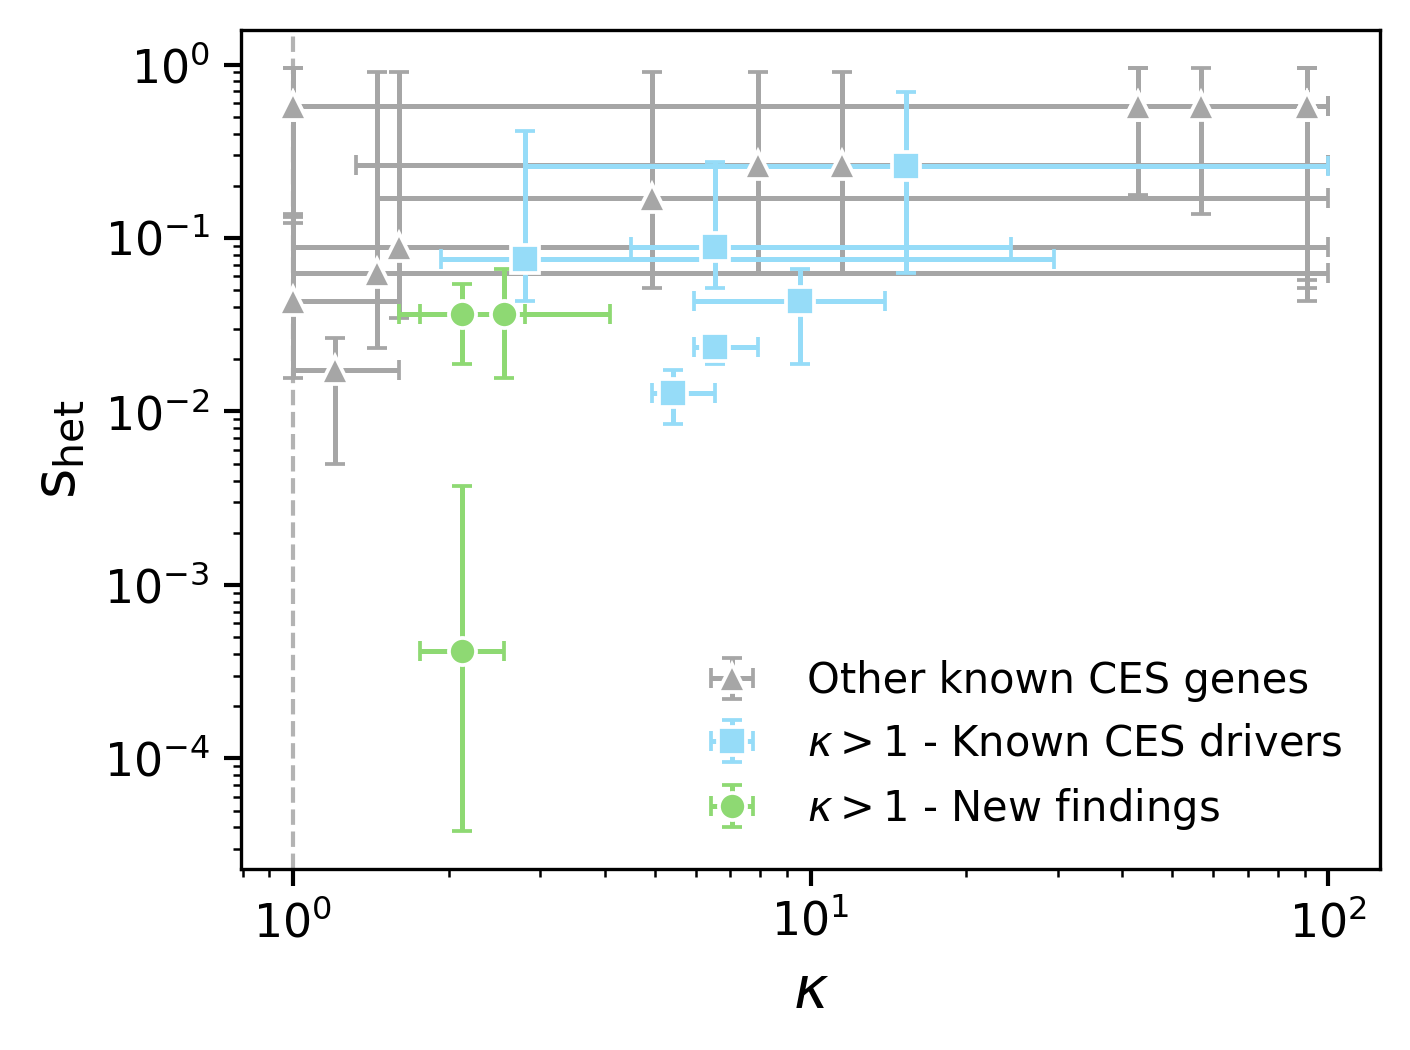

In [14]:
fig, ax = plot_selected_red_blue_profile(
    df_mle=df_mle,
    CES_genes_PIES=CES_genes_this_work,
    new_genes=new_genes,
    CES_genes_previous=CES_genes_previous,
    outfile="../Figures/kappa_vs_s_mle.svg"
)